# Graph Anomaly Detection with DGM & friends

Notebook di test.

## 0. Setup

Impostiamo path, seed e device.  
Importiamo un po' di librerie.


In [1]:
from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project:", PROJECT_DIR)
print("Device:", DEVICE)


Project: /home/marco/projects/graph_anomaly_detection
Device: cuda


In [2]:
from functions.data_utils import generate_synthetic_water_like, load_synthetic_water_npz
from functions.graph_utils import (
    knn_graph_from_positions,
    topology_metrics,
    edge_set_to_edge_index,
    edge_index_to_edge_set,
)
from functions.dgm_module import DGMNodeAnomalyModel
from functions.loss_utils import combine_task_and_topology_loss
from functions.plot_utils import plot_node_anomaly_graph

print("Local project functions imported correctly.")


Local project functions imported correctly.


## 1. Configurazione

Tutte gli iperparametri modificabili stanno qui: dataset, feature, DGM, training e modalità di unificazione del grafo statico.


In [3]:
from dataclasses import dataclass, field


@dataclass
class DatasetConfig:
    data_npz: str | None = None
    anomaly_fraction: float = 0.15
    anomaly_feature: str = "demand"   # "pressure", "demand", "both"
    seed: int = 42


@dataclass
class FeatureConfig:
    active_groups: list[str] = field(default_factory=lambda: [
        "geometric",
        "pressure",
        "demand",
        "temporal",
    ])

    available_groups: dict = field(default_factory=lambda: {
        "geometric": ["x_coord", "y_coord"],
        "pressure": ["pressure_mean", "pressure_std", "pressure_trend"],
        "demand": ["demand_mean", "demand_std", "demand_trend"],
        "temporal": ["pressure_trend", "demand_trend"],
        "iot_communication": [],
        "iot_context": [],
        "iot_knowledge": [],
    })


@dataclass
class DGMConfig:
    hidden_dim: int = 32
    latent_dim: int = 8
    k: int = 2
    dropout: float = 0.10


@dataclass
class TrainingConfig:
    task: str = "node_level_anomaly_detection"
    epochs: int = 100
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    pos_weight: float | None = None
    grad_clip_norm: float = 1.0


@dataclass
class LossConfig:
    # Se use_topology_loss=True serve data.pos, perche' la loss topologica usa le coordinate (visto che per ora abbiamo solo le distanze tra nodi come attributo).
    use_topology_loss: bool = True  # oppure False
    alpha_task: float = 0.7  # total = alpha * task + (1-alpha) * topology


@dataclass
class ConsensusConfig:
    method: str = "edge_frequency_threshold"
    frequency_threshold: float = 0.80
    mean_adjacency_threshold: float = 0.80
    top_edges: int | None = None
    beta_std_penalty: float = 0.80


@dataclass
class VisualizationConfig:
    node_size: int = 90
    graph_epochs_to_show: list[int] = field(default_factory=lambda: [10, 30, 50])


@dataclass
class ExperimentConfig:
    dataset: DatasetConfig = field(default_factory=DatasetConfig)
    features: FeatureConfig = field(default_factory=FeatureConfig)
    dgm: DGMConfig = field(default_factory=DGMConfig)
    training: TrainingConfig = field(default_factory=TrainingConfig)
    loss: LossConfig = field(default_factory=LossConfig)
    consensus: ConsensusConfig = field(default_factory=ConsensusConfig)
    visualization: VisualizationConfig = field(default_factory=VisualizationConfig)


config = ExperimentConfig()

print("Task:", config.training.task)
print("Feature groups:", config.features.active_groups)
print("DGM: k =", config.dgm.k, "| latent_dim =", config.dgm.latent_dim)
print("Epochs:", config.training.epochs)
print("Loss alpha_task:", config.loss.alpha_task, "| topology enabled:", config.loss.use_topology_loss)
print("Consensus:", config.consensus.method)


Task: node_level_anomaly_detection
Feature groups: ['geometric', 'pressure', 'demand', 'temporal']
DGM: k = 2 | latent_dim = 8
Epochs: 100
Loss alpha_task: 0.7 | topology enabled: True
Consensus: edge_frequency_threshold


## 2. Dataset Sintetico

Per ora le anomalie sono **node-level persistenti**: alcuni nodi sono marcati come anomali e i loro valori sono alterati lungo tutta la serie temporale sintetica.

Qui bisogna in caso adattare per prendere in input un dataset reale o un dataset sintetico diverso.  

In [4]:
if config.dataset.data_npz is not None:
    data = load_synthetic_water_npz(
        path=config.dataset.data_npz,
        seed=config.dataset.seed,
        anomaly_fraction=config.dataset.anomaly_fraction,
    )
else:
    data = generate_synthetic_water_like(
        seed=config.dataset.seed,
        anomaly_fraction=config.dataset.anomaly_fraction,
        anomaly_feature=config.dataset.anomaly_feature,
    )

print("X:", data.X.shape)
print("y:", data.y.shape)
print("pos:", data.pos.shape)
print("true edges:", data.edge_index_true.shape)
print("initial edges:", data.edge_index_initial.shape)
print("features:", data.feature_names)
print("metadata:", data.metadata)

print("\nNodes:", data.X.shape[0])
print("Anomalous nodes:", int(data.y.sum()))
print("Anomaly ratio:", round(float(data.y.mean()), 3))
print("Masks:", {
    "train": int(data.train_mask.sum()),
    "val": int(data.val_mask.sum()),
    "test": int(data.test_mask.sum()),
})


X: (50, 8)
y: (50,)
pos: (50, 2)
true edges: (2, 194)
initial edges: (2, 136)
features: ['x_coord', 'y_coord', 'pressure_mean', 'pressure_std', 'demand_mean', 'demand_std', 'pressure_trend', 'demand_trend']
metadata: {'source': 'generated_synthetic_water_like', 'anomaly_nodes': [9, 21, 44, 23, 26, 35, 38]}

Nodes: 50
Anomalous nodes: 7
Anomaly ratio: 0.14
Masks: {'train': 30, 'val': 10, 'test': 10}


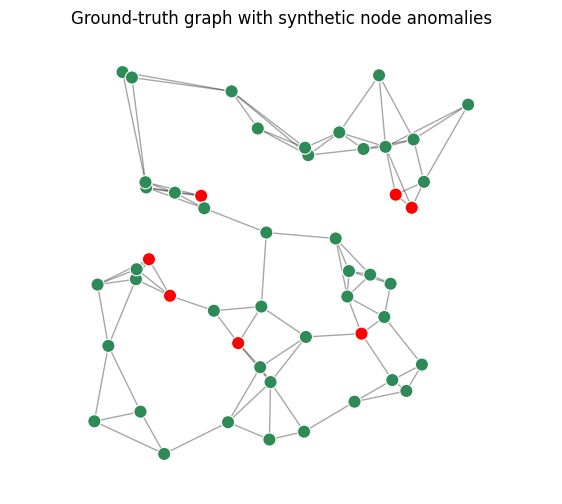

In [5]:
plot_node_anomaly_graph(
    edge_index=data.edge_index_true,
    pos=data.pos,
    y=data.y,
    title="Ground-truth graph with synthetic node anomalies",
    node_size=config.visualization.node_size,
)


## 3. Feature Selection

La matrice `data.X` contiene tutte le feature disponibili. Qui scegliamo solo i gruppi indicati in `config.features.active_groups`.  

Queste feature che descrivono i nodi dipendono molto dalla strategia che decidi di adottare (io li ho impostati abbastanza a caso), e dal dataset che stai gestendo.


In [6]:
def select_feature_groups(data, feature_config):
    selected_names = []
    for group_name in feature_config.active_groups:
        if group_name not in feature_config.available_groups:
            raise ValueError(f"Unknown feature group: {group_name}")
        selected_names.extend(feature_config.available_groups[group_name])

    selected_names = list(dict.fromkeys(selected_names))
    name_to_idx = {name: idx for idx, name in enumerate(data.feature_names)}
    missing = [name for name in selected_names if name not in name_to_idx]
    if missing:
        raise ValueError(f"Selected features not present in data: {missing}")

    selected_indices = [name_to_idx[name] for name in selected_names]
    return data.X[:, selected_indices], selected_names, selected_indices


X_selected, selected_feature_names, selected_feature_indices = select_feature_groups(
    data=data,
    feature_config=config.features,
)

print("Selected feature names:", selected_feature_names)
print("X_selected:", X_selected.shape)

pd.DataFrame(X_selected, columns=selected_feature_names).head()


Selected feature names: ['x_coord', 'y_coord', 'pressure_mean', 'pressure_std', 'pressure_trend', 'demand_mean', 'demand_std', 'demand_trend']
X_selected: (50, 8)


,x_coord,y_coord,pressure_mean,pressure_std,pressure_trend,demand_mean,demand_std,demand_trend
0,1.093278,-0.197100,-0.538894,-1.617947,0.241428,-0.047627,-0.283704,0.122301
1,1.408325,0.740705,0.811537,1.130674,0.033969,-0.822070,-0.425378,-0.163629
2,-1.436938,1.750216,0.296586,0.576196,0.811530,-0.513047,-0.365542,0.209145
3,1.045574,1.062496,-1.419780,1.590958,-0.148126,0.505176,-0.345633,0.505189
4,-1.310623,-0.155350,0.289502,-0.551745,-0.480077,-0.498553,-0.280910,0.285484


## 4. Grafo Iniziale E Ground Truth

Qui separiamo chiaramente tre oggetti diversi.

1. **Ground truth graph**: e' il grafo reale/sintetico completo. Nel setting principale viene tenuto fuori dal training e usato solo alla fine per valutare quanto bene abbiamo ricostruito la topologia.

2. **Backbone iniziale**: e' un grafo debole costruito con un metodo semplice e dichiarato, per esempio kNN sulle coordinate oppure `dataset_initial` se disponibile. Questo backbone non e' il risultato finale: serve come contesto iniziale per il DGM, in modo coerente con l'idea secondo cui l'embedding del DGM puo' ricevere un `edge_index` iniziale (ovviamente cambiare la strategia iniziale di backbone è super influente sui risultati).

3. **Grafo dinamico DGM**: durante il training il DGM aggiorna/ricostruisce il grafo a partire dalle rappresentazioni latenti. La loss puo' essere solo di task oppure complementare:

```python
total_loss = alpha_task * task_loss + (1 - alpha_task) * topology_loss
```

Per ora `topology_loss` e' una componente semplice: penalizza archi probabili ma geometricamente lunghi. Questa parte puo' essere usata solo se abbiamo `pos`, cioe' le coordinate dei nodi.

Quindi il flusso e': teniamo il ground truth fuori dal training, costruiamo un backbone iniziale semplice, passiamo il backbone al DGM come contesto, alleniamo con task loss o task+topology loss, salviamo la storia dei grafi e poi costruiamo un consensus graph statico.


In [7]:
GRAPH_INIT_MODE = "knn_geometry"  # "dataset_initial", "knn_geometry", "learned_from_scratch"
GRAPH_KNN_K = 2

edge_index_true = data.edge_index_true
edge_index_dataset_initial = data.edge_index_initial
edge_index_knn = knn_graph_from_positions(data.pos, k=GRAPH_KNN_K, bidirectional=True)

if GRAPH_INIT_MODE == "dataset_initial":
    edge_index_initial = edge_index_dataset_initial
elif GRAPH_INIT_MODE == "knn_geometry":
    edge_index_initial = edge_index_knn
elif GRAPH_INIT_MODE == "learned_from_scratch":
    edge_index_initial = None
else:
    raise ValueError(f"Unknown GRAPH_INIT_MODE: {GRAPH_INIT_MODE}")

print("Graph init mode:", GRAPH_INIT_MODE)
print("Ground-truth edges:", edge_index_true.shape)
print("Selected initial graph:", None if edge_index_initial is None else edge_index_initial.shape)

if edge_index_initial is not None:
    init_vs_true = topology_metrics(edge_index_true, edge_index_initial, data.X.shape[0])
    print("Initial graph vs ground truth:", init_vs_true)


if edge_index_initial is not None:
    initial_edge_index_tensor = torch.tensor(
        edge_index_initial,
        dtype=torch.long,
        device=DEVICE,
    )
else:
    initial_edge_index_tensor = None

Graph init mode: knn_geometry
Ground-truth edges: (2, 194)
Selected initial graph: (2, 136)
Initial graph vs ground truth: {'tp': 68, 'fp': 0, 'fn': 29, 'precision': 1.0, 'recall': 0.7010309278350515, 'f1': 0.8242424242424242, 'structural_hamming_distance': 29, 'possible_undirected_edges': 1225}


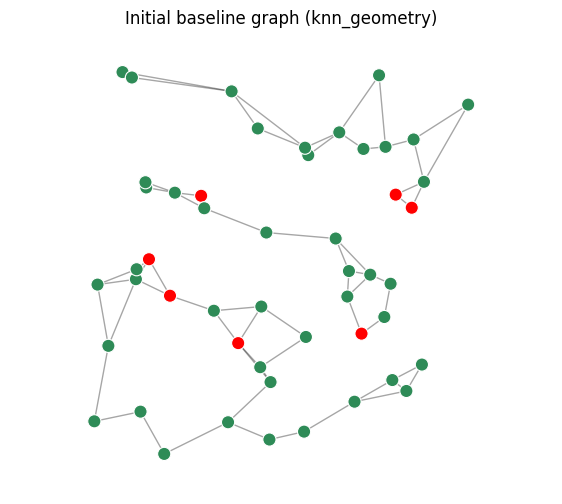

In [8]:
if edge_index_initial is not None:
    plot_node_anomaly_graph(
        edge_index=edge_index_initial,
        pos=data.pos,
        y=data.y,
        title=f"Initial baseline graph ({GRAPH_INIT_MODE})",
        node_size=config.visualization.node_size,
    )


## 5. Modello DGM Per Node Anomaly Detection

Il modello produce un logit per nodo e un grafo latente dinamico a ogni forward.


In [9]:
X_tensor = torch.tensor(X_selected, dtype=torch.float32, device=DEVICE)
y_tensor = torch.tensor(data.y, dtype=torch.float32, device=DEVICE)
train_mask_tensor = torch.tensor(data.train_mask, dtype=torch.bool, device=DEVICE)
val_mask_tensor = torch.tensor(data.val_mask, dtype=torch.bool, device=DEVICE)
test_mask_tensor = torch.tensor(data.test_mask, dtype=torch.bool, device=DEVICE)
pos_tensor = torch.tensor(data.pos, dtype=torch.float32, device=DEVICE) if data.pos is not None else None

model = DGMNodeAnomalyModel(
    input_dim=X_tensor.shape[1],
    hidden_dim=config.dgm.hidden_dim,
    latent_dim=config.dgm.latent_dim,
    k=config.dgm.k,
    dropout=config.dgm.dropout,
).to(DEVICE)

model.eval()
with torch.no_grad():
    output_0 = model(X_tensor, initial_edge_index=initial_edge_index_tensor)

print("logits:", output_0["logits"].shape)
print("embeddings:", output_0["embeddings"].shape)
print("learned edge_index:", output_0["edge_index"].shape)
print("edge_probs:", output_0["edge_probs"].shape)


logits: torch.Size([50])
embeddings: torch.Size([50, 32])
learned edge_index: torch.Size([2, 100])
edge_probs: torch.Size([50, 50])


## 6. Loss

Usiamo `BCEWithLogitsLoss`, calcolata solo sui nodi di training. `pos_weight` aiuta quando le anomalie sono poche.


In [10]:
def compute_pos_weight(y, train_mask):
    y_train = y[train_mask]
    n_pos = int(y_train.sum())
    n_neg = int(len(y_train) - n_pos)
    if n_pos == 0:
        return None
    return n_neg / max(n_pos, 1)


def compute_node_anomaly_loss(output, y, mask, criterion):
    return criterion(output["logits"][mask], y[mask])


def compute_training_loss(output, y, mask, criterion, pos, loss_config):
    task_loss = compute_node_anomaly_loss(output, y, mask, criterion)
    return combine_task_and_topology_loss(
        task_loss=task_loss,
        edge_probs=output["edge_probs"],
        pos=pos,
        alpha_task=loss_config.alpha_task,
        use_topology_loss=loss_config.use_topology_loss,
    )


pos_weight_value = (
    compute_pos_weight(data.y, data.train_mask)
    if config.training.pos_weight is None
    else config.training.pos_weight
)

if pos_weight_value is not None:
    pos_weight_tensor = torch.tensor(pos_weight_value, dtype=torch.float32, device=DEVICE)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
else:
    criterion = torch.nn.BCEWithLogitsLoss()

loss_check = compute_training_loss(output_0, y_tensor, train_mask_tensor, criterion, pos_tensor, config.loss)

print("Task loss: BCEWithLogitsLoss")
print("Topology loss: normalized edge length" if config.loss.use_topology_loss else "Topology loss: disabled")
print("Formula: total = alpha_task * task + (1 - alpha_task) * topology")
print("alpha_task:", config.loss.alpha_task)
print("pos_weight:", pos_weight_value)
print("Initial total loss:", float(loss_check["total_loss"].detach().cpu()))
print("Initial task loss:", float(loss_check["task_loss"].detach().cpu()))
print("Initial topology loss:", float(loss_check["topology_loss"].detach().cpu()))


Task loss: BCEWithLogitsLoss
Topology loss: normalized edge length
Formula: total = alpha_task * task + (1 - alpha_task) * topology
alpha_task: 0.7
pos_weight: 5.0
Initial total loss: 1.0153058767318726
Initial task loss: 1.308115005493164
Initial topology loss: 0.33208465576171875


## 7. Training

Il training può sembrare istantaneo perché questo smoke test è minuscolo: 50 nodi, full-batch training, niente DataLoader e un modello molto piccolo. Su dataset reali o finestre temporali più grandi sarà più lento.


In [11]:
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)


def evaluate_node_predictions(logits, y, mask):
    scores = torch.sigmoid(logits[mask]).detach().cpu().numpy()
    y_true = y[mask].detach().cpu().numpy().astype(int)

    if not np.isfinite(scores).all():
        raise ValueError("Validation scores contain NaN/Inf. Check learning rate, alpha_task, or topology loss scale.")

    y_pred = (scores >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, scores) if len(set(y_true)) > 1 else np.nan,
        "roc_auc": roc_auc_score(y_true, scores) if len(set(y_true)) > 1 else np.nan,
    }


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.training.learning_rate,
    weight_decay=config.training.weight_decay,
)

training_output = {
    "history": {"epoch": [], "train_loss": [], "task_loss": [], "topology_loss": [], "val_loss": [], "val_f1": [], "val_roc_auc": [], "num_edges": []},
    "graph_history": [],
    "edge_probability_history": [],
    "embedding_history": [],
}

start_time = time.time()
progress = tqdm(range(1, config.training.epochs + 1), desc="Training")

for epoch in progress:
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor, initial_edge_index=initial_edge_index_tensor)
    losses = compute_training_loss(output, y_tensor, train_mask_tensor, criterion, pos_tensor, config.loss)
    train_loss = losses["total_loss"]

    if not torch.isfinite(train_loss):
        raise ValueError("Training loss became NaN/Inf. Try alpha_task closer to 1.0 or disable topology loss.")

    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.training.grad_clip_norm)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(X_tensor, initial_edge_index=initial_edge_index_tensor)
        val_loss = compute_node_anomaly_loss(val_output, y_tensor, val_mask_tensor, criterion)
        val_metrics = evaluate_node_predictions(val_output["logits"], y_tensor, val_mask_tensor)

    edge_index_epoch = val_output["edge_index"].detach().cpu().numpy()
    edge_probs_epoch = val_output["edge_probs"].detach().cpu().numpy()

    training_output["graph_history"].append(edge_index_epoch)
    training_output["edge_probability_history"].append(edge_probs_epoch)
    training_output["embedding_history"].append(val_output["embeddings"].detach().cpu().numpy())

    h = training_output["history"]
    h["epoch"].append(epoch)
    h["train_loss"].append(float(train_loss.detach().cpu()))
    h["task_loss"].append(float(losses["task_loss"].detach().cpu()))
    h["topology_loss"].append(float(losses["topology_loss"].detach().cpu()))
    h["val_loss"].append(float(val_loss.detach().cpu()))
    h["val_f1"].append(float(val_metrics["f1"]))
    h["val_roc_auc"].append(float(val_metrics["roc_auc"]))
    h["num_edges"].append(edge_index_epoch.shape[1])

    progress.set_postfix(
        total=f"{h['train_loss'][-1]:.4f}",
        task=f"{h['task_loss'][-1]:.4f}",
        topo=f"{h['topology_loss'][-1]:.4f}",
        val_f1=f"{h['val_f1'][-1]:.3f}",
    )

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training completed in 1.85 seconds.


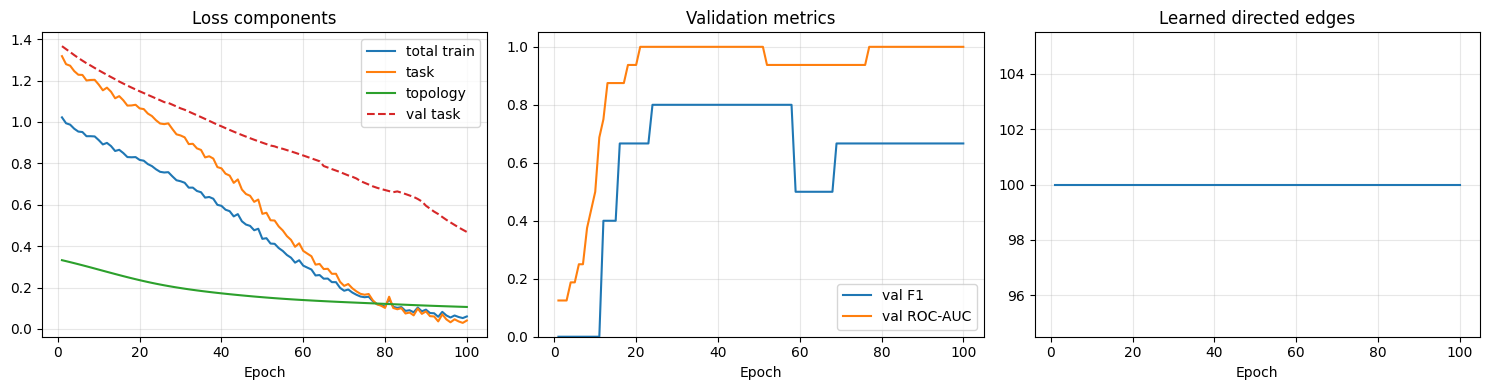

In [12]:
history = training_output["history"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["epoch"], history["train_loss"], label="total train")
axes[0].plot(history["epoch"], history["task_loss"], label="task")
if config.loss.use_topology_loss:
    axes[0].plot(history["epoch"], history["topology_loss"], label="topology")
axes[0].plot(history["epoch"], history["val_loss"], label="val task", linestyle="--")
axes[0].set_title("Loss components")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history["epoch"], history["val_f1"], label="val F1")
axes[1].plot(history["epoch"], history["val_roc_auc"], label="val ROC-AUC")
axes[1].set_title("Validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(history["epoch"], history["num_edges"])
axes[2].set_title("Learned directed edges")
axes[2].set_xlabel("Epoch")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Evoluzione Dei Grafi Dinamici

Prima del consensus (messa insieme dei grafi di ogni epoca), guardiamo alcuni grafi prodotti dal DGM durante il training. Gli indici sono configurabili in `config.visualization.graph_epochs_to_show`.


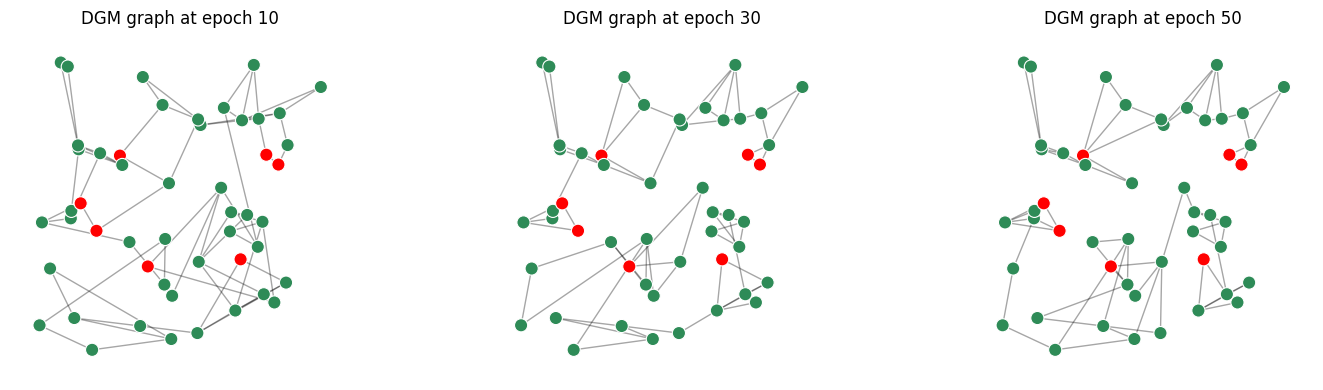

In [13]:
def draw_graph_on_axis(ax, edge_index, pos, node_labels, title):
    G = nx.Graph()
    G.add_nodes_from(range(len(node_labels)))
    G.add_edges_from(edge_index.T.tolist())
    node_pos = {i: (float(pos[i, 0]), float(pos[i, 1])) for i in range(len(node_labels))}
    node_colors = ["red" if int(label) == 1 else "seagreen" for label in node_labels]
    nx.draw_networkx_edges(G, node_pos, ax=ax, alpha=0.35, width=1.0)
    nx.draw_networkx_nodes(
        G,
        node_pos,
        ax=ax,
        node_color=node_colors,
        node_size=config.visualization.node_size,
        edgecolors="white",
        linewidths=0.8,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


epochs_to_show = [
    epoch for epoch in config.visualization.graph_epochs_to_show
    if 1 <= epoch <= len(training_output["graph_history"])
]

fig, axes = plt.subplots(1, len(epochs_to_show), figsize=(5 * len(epochs_to_show), 4))
if len(epochs_to_show) == 1:
    axes = [axes]

for ax, epoch in zip(axes, epochs_to_show):
    draw_graph_on_axis(
        ax=ax,
        edge_index=training_output["graph_history"][epoch - 1],
        pos=data.pos,
        node_labels=data.y,
        title=f"DGM graph at epoch {epoch}",
    )

plt.tight_layout()
plt.show()


## 9. Consensus Graph

Aggrega i grafi dinamici in un grafo statico. Il default è semplice e interpretabile: frequency threshold.


In [14]:
from collections import Counter


def edge_frequency_matrix(graph_history, num_nodes):
    counts = np.zeros((num_nodes, num_nodes), dtype=float)
    for edge_index in graph_history:
        edges = edge_index_to_edge_set(edge_index, undirected=True)
        for u, v in edges:
            counts[u, v] += 1
            counts[v, u] += 1
    frequency = counts / max(1, len(graph_history))
    np.fill_diagonal(frequency, 0.0)
    return frequency


def build_consensus_graph(graph_history, num_nodes, method, config):
    frequency = edge_frequency_matrix(graph_history, num_nodes)

    if method in {"edge_frequency_threshold", "mean_adjacency_threshold"}:
        threshold = (
            config.frequency_threshold
            if method == "edge_frequency_threshold"
            else config.mean_adjacency_threshold
        )
        A = (frequency >= threshold).astype(float)

    elif method == "top_frequency":
        if config.top_edges is None:
            raise ValueError("config.top_edges must be set for top_frequency")
        A = np.zeros_like(frequency)
        pairs = [(frequency[i, j], i, j) for i in range(num_nodes) for j in range(i + 1, num_nodes)]
        for _, i, j in sorted(pairs, reverse=True)[:config.top_edges]:
            A[i, j] = A[j, i] = 1.0
    else:
        raise ValueError(f"Unknown consensus method: {method}")

    edges = {(i, j) for i in range(num_nodes) for j in range(i + 1, num_nodes) if A[i, j] > 0}
    return edge_set_to_edge_index(edges, bidirectional=True), A, {
        "method": method,
        "num_dynamic_graphs": len(graph_history),
        "num_consensus_undirected_edges": len(edges),
        "frequency_matrix": frequency,
        "adjacency_consensus": A,
    }


consensus_edge_index, A_consensus, consensus_info = build_consensus_graph(
    graph_history=training_output["graph_history"],
    num_nodes=data.X.shape[0],
    method=config.consensus.method,
    config=config.consensus,
)

frequency_matrix = consensus_info["frequency_matrix"]

print("Consensus method:", consensus_info["method"])
print("Dynamic graphs:", consensus_info["num_dynamic_graphs"])
print("Consensus undirected edges:", consensus_info["num_consensus_undirected_edges"])


Consensus method: edge_frequency_threshold
Dynamic graphs: 100
Consensus undirected edges: 38


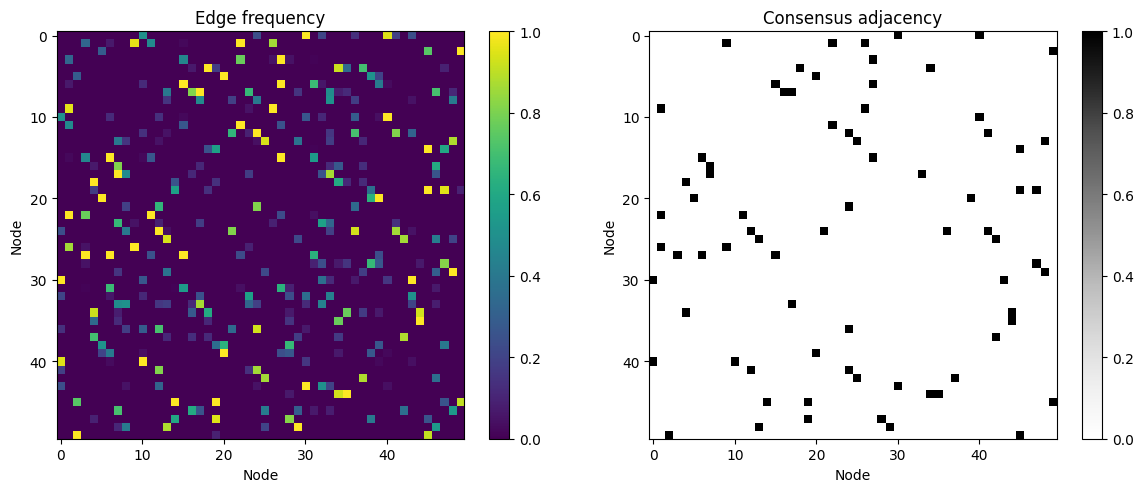

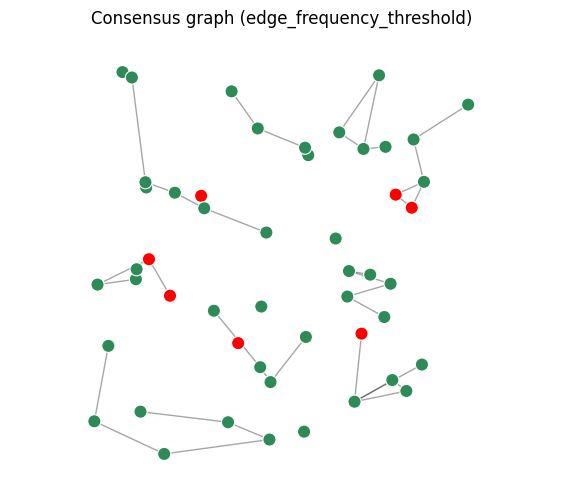

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(frequency_matrix, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Edge frequency")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(A_consensus, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("Consensus adjacency")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

plot_node_anomaly_graph(
    edge_index=consensus_edge_index,
    pos=data.pos,
    y=data.y,
    title=f"Consensus graph ({config.consensus.method})",
    node_size=config.visualization.node_size,
)


## 10. Anomaly Detection Finale

Convertiamo i logits in anomaly score e calcoliamo metriche sui tre split.


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    final_output = model(X_tensor,  initial_edge_index=initial_edge_index_tensor)
    anomaly_scores = torch.sigmoid(final_output["logits"]).detach().cpu().numpy()

anomaly_threshold = 0.50
y_pred_all = (anomaly_scores >= anomaly_threshold).astype(int)
y_true_all = data.y.astype(int)


def report_split_metrics(split_name, mask):
    mask_np = np.asarray(mask).astype(bool)
    y_true = y_true_all[mask_np]
    y_pred = y_pred_all[mask_np]
    scores = anomaly_scores[mask_np]
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, scores) if len(set(y_true)) > 1 else np.nan,
        "roc_auc": roc_auc_score(y_true, scores) if len(set(y_true)) > 1 else np.nan,
    }
    print(f"\n{split_name.upper()} metrics")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")
    return metrics


final_metrics = {
    "train": report_split_metrics("train", data.train_mask),
    "val": report_split_metrics("val", data.val_mask),
    "test": report_split_metrics("test", data.test_mask),
}



TRAIN metrics
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
pr_auc: 1.0000
roc_auc: 1.0000

VAL metrics
accuracy: 0.9000
precision: 1.0000
recall: 0.5000
f1: 0.6667
pr_auc: 1.0000
roc_auc: 1.0000

TEST metrics
accuracy: 1.0000
precision: 0.0000
recall: 0.0000
f1: 0.0000
pr_auc: nan
roc_auc: nan


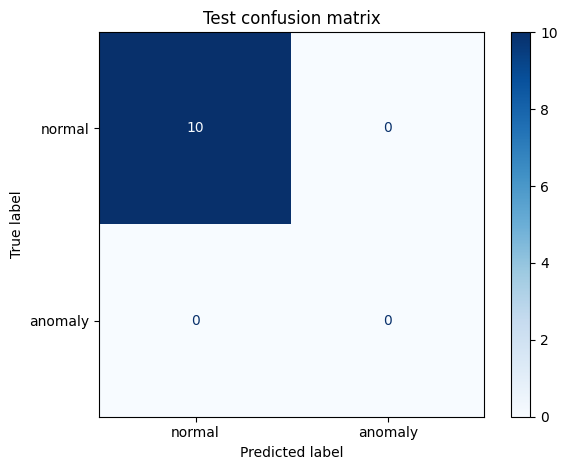

,node,true_label,pred_label,anomaly_score
9,9,1,1,0.995787
26,26,1,1,0.995398
21,21,1,1,0.985567
23,23,1,1,0.972253
38,38,1,1,0.962833
35,35,1,1,0.937765
44,44,1,0,0.448458
22,22,0,0,0.122120
1,1,0,0,0.112240
3,3,0,0,0.107327


In [17]:
cm = confusion_matrix(y_true_all[data.test_mask], y_pred_all[data.test_mask], labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "anomaly"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "node": np.arange(len(y_true_all)),
    "true_label": y_true_all,
    "pred_label": y_pred_all,
    "anomaly_score": anomaly_scores,
})
comparison.sort_values("anomaly_score", ascending=False).head(10)


## 11. Riepilogo E Visualizzazioni Finali


In [18]:
initial_topology = None
if edge_index_initial is not None:
    initial_topology = topology_metrics(edge_index_true, edge_index_initial, data.X.shape[0])

consensus_topology = topology_metrics(edge_index_true, consensus_edge_index, data.X.shape[0])

topology_summary_rows = []
if initial_topology is not None:
    topology_summary_rows.append({"graph": "initial", **initial_topology})
topology_summary_rows.append({"graph": "consensus", **consensus_topology})

topology_summary = pd.DataFrame(topology_summary_rows)
anomaly_summary = pd.DataFrame([{"split": split, **metrics} for split, metrics in final_metrics.items()])

display(topology_summary)
display(anomaly_summary)


,graph,tp,fp,fn,precision,recall,f1,structural_hamming_distance,possible_undirected_edges
0,initial,68,0,29,1.000000,0.701031,0.824242,29,1225
1,consensus,31,7,66,0.815789,0.319588,0.459259,73,1225


,split,accuracy,precision,recall,f1,pr_auc,roc_auc
0,train,1.0,1.0,1.0,1.000000,1.0,1.0
1,val,0.9,1.0,0.5,0.666667,1.0,1.0
2,test,1.0,0.0,0.0,0.000000,NaN,NaN


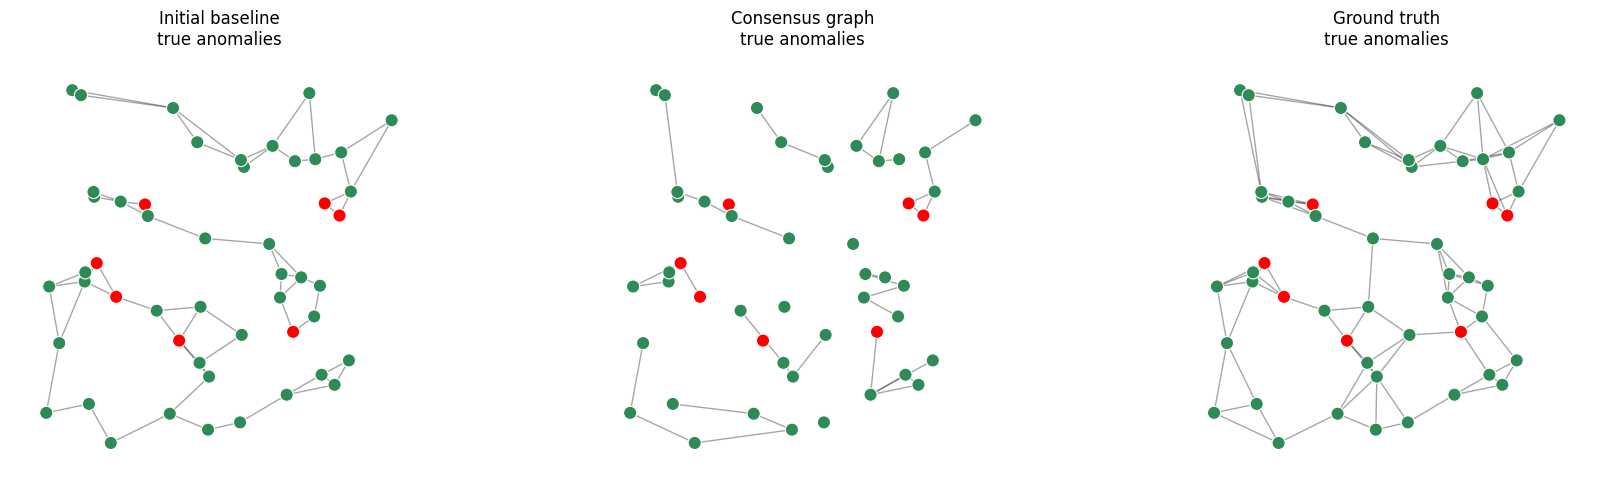

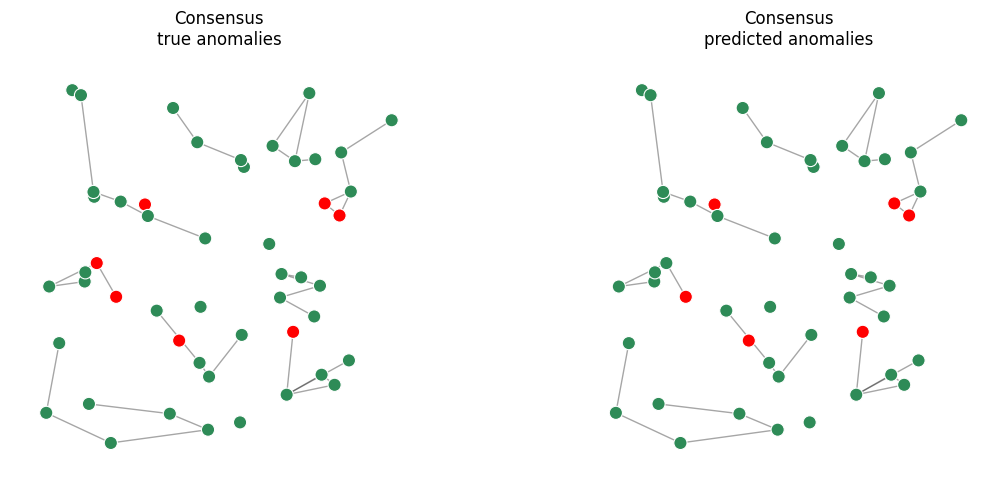

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if edge_index_initial is not None:
    draw_graph_on_axis(axes[0], edge_index_initial, data.pos, data.y, "Initial baseline\ntrue anomalies")
else:
    axes[0].set_title("No initial graph")
    axes[0].axis("off")

draw_graph_on_axis(axes[1], consensus_edge_index, data.pos, data.y, "Consensus graph\ntrue anomalies")
draw_graph_on_axis(axes[2], edge_index_true, data.pos, data.y, "Ground truth\ntrue anomalies")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_graph_on_axis(axes[0], consensus_edge_index, data.pos, data.y, "Consensus\ntrue anomalies")
draw_graph_on_axis(axes[1], consensus_edge_index, data.pos, y_pred_all, "Consensus\npredicted anomalies")
plt.tight_layout()
plt.show()


In [20]:
experiment_summary = {
    "task": config.training.task,
    "feature_groups": config.features.active_groups,
    "selected_features": selected_feature_names,
    "dgm_k": config.dgm.k,
    "dgm_hidden_dim": config.dgm.hidden_dim,
    "dgm_latent_dim": config.dgm.latent_dim,
    "epochs": config.training.epochs,
    "consensus_method": config.consensus.method,
    "consensus_edges": consensus_info["num_consensus_undirected_edges"],
    "test_f1": final_metrics["test"]["f1"],
    "test_roc_auc": final_metrics["test"]["roc_auc"],
    "topology_f1_consensus": consensus_topology["f1"],
}

experiment_summary


{'task': 'node_level_anomaly_detection',
 'feature_groups': ['geometric', 'pressure', 'demand', 'temporal'],
 'selected_features': ['x_coord',
  'y_coord',
  'pressure_mean',
  'pressure_std',
  'pressure_trend',
  'demand_mean',
  'demand_std',
  'demand_trend'],
 'dgm_k': 2,
 'dgm_hidden_dim': 32,
 'dgm_latent_dim': 8,
 'epochs': 100,
 'consensus_method': 'edge_frequency_threshold',
 'consensus_edges': 38,
 'test_f1': 0.0,
 'test_roc_auc': nan,
 'topology_f1_consensus': 0.4592592592592593}

# Nota metodologica: dataset sintetico e differenza rispetto al paper (IMPORTANTE!!!)

In questo primo notebook usiamo un dataset sintetico water-like semplificato.  
I segnali di pressione e domanda possono essere pensati come segnali temporali generati per ogni nodo, ma in questa prima versione non passiamo al modello tutta la serie temporale. La riassumiamo invece con feature aggregate per nodo, ad esempio media, deviazione standard e trend.

Quindi il modello riceve una matrice del tipo:

```python
X.shape = [num_nodes, num_node_features]
```
e non una sequenza temporale del tipo:

```python
X.shape = [nuX_time.shape = [num_nodes, num_timesteps, num_features]m_nodes, num_node_features]
```

Nel paper di riferimento, invece, l'anomaly detection è più vicina a un problema edge-level su traffico IoT. Gli autori partono da flussi di rete nel tempo, costruiscono grafi dinamici tramite sliding window, usano diversi tipi di relazione tra dispositivi e classificano come anomali certi archi o comunicazioni.  

In forma sintetica, il paper segue una logica del tipo:

network flows nel tempo
    -> sliding window temporale
    -> multi-edge graph per finestra
    -> community detection
    -> HeteroGNN
    -> classificazione di archi/flussi anomali

Il nostro primo notebook segue invece una logica più semplice:

segnali water sintetici
    -> feature aggregate per nodo
    -> DGM per apprendere/aggiornare il grafo
    -> consensus graph
    -> anomaly detection node-level

Ne stiamo riusando l'idea generale: contesti diversi possono produrre relazioni diverse, il grafo può evolvere durante il training, la stabilità degli archi è informativa e un consensus graph finale può essere utile per anomaly detection.

NB: al momento l'architettura funziona solo nel caso supervisionato (anomalie etichettate); eventualmente va adattata al caso semi-supervisionato se il dataset lo richiede.
Possibili estensioni, dalla più semplice alla più complessa:

1) Feature aggregate per nodo, versione attuale.

2) Finestre temporali aggregate.
La serie temporale viene divisa in finestre e per ogni finestra si calcolano feature aggregate. In questo modo si può osservare come cambiano feature, grafi e anomalie nel tempo.

3) Encoder temporale per nodo.
Il modello riceve direttamente X_time = [num_nodes, num_timesteps, num_features]. Un encoder semplice, per esempio MLP temporale, CNN 1D o GRU, produce embedding dei nodi da passare al DGM.

4) Grafi dinamici per finestra e anomaly detection edge-level (DIPENDE MOLTO DAI DATI: ANOMALIA VALORE LETTO AL SENSORE O ANOMALIA COLLEGAMENTO?).
È la versione più vicina al paper. Per ogni finestra temporale si costruisce o apprende un grafo, si salvano le probabilità degli archi e si classificano anomalie su nodi o archi.
